# MintPy Product Inspection Notebook

This notebook helps inspect and validate:

* MintPy velocity products
* Temporal coherence
* Common masks
* ASC/DESC decomposition outputs
* Basic statistics
* Histograms
* Raster visualization
* Time series inspection

It is designed for your current workflow outputs.

# 1. Imports

In [1]:
import os
import h5py
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

# 2. Define Product Paths

Adjust paths if needed.

In [2]:
BASE_DIR = Path("~/projects/ADUCAT/data/Mintpy_output").expanduser()

ASC_DIR = BASE_DIR / "stack_Ascending_73_20200604_20200628_c2_z2_r6_f0.5_mintpy"
DESC_DIR = BASE_DIR / "stack_Descending_124_20200602_20200626_c2_z2_r6_f0.5_mintpy"

DECOMP_DIR = BASE_DIR / "decomposition"

ASC_GEO = ASC_DIR / "geo_standardized"
DESC_GEO = DESC_DIR / "geo_standardized"

# 3. Helper Functions

## Inspect HDF5 structure

In [41]:
def inspect_h5(h5_file):
    
    print(f"\n=== {h5_file} ===")

    with h5py.File(h5_file, "r") as f:

        print("\nDatasets:")
        for key in f.keys():
            print(f"  - {key}: {f[key].shape}")

        print("\nAttributes:")
        for key, value in f.attrs.items():
            print(f"  {key}: {value}")

## Read first dataset automatically

In [42]:
def read_first_dataset(h5_file):

    with h5py.File(h5_file, "r") as f:

        dataset_name = list(f.keys())[0]

        data = f[dataset_name][:]

        return dataset_name, data

## Plot raster

In [43]:
def plot_raster(
    data,
    title="Raster",
    cmap="viridis",
    vmin=None,
    vmax=None,
    figsize=(10, 8)
):

    plt.figure(figsize=figsize)

    plt.imshow(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Compute statistics

In [44]:
def compute_statistics(data):

    valid = data[np.isfinite(data)]

    stats = {
        "count": valid.size,
        "min": np.min(valid),
        "max": np.max(valid),
        "mean": np.mean(valid),
        "std": np.std(valid),
        "p01": np.percentile(valid, 1),
        "p05": np.percentile(valid, 5),
        "p50": np.percentile(valid, 50),
        "p95": np.percentile(valid, 95),
        "p99": np.percentile(valid, 99),
        "nan_ratio": np.isnan(data).sum() / data.size,
    }

    return pd.Series(stats)

## Plot histogram

In [45]:
def plot_histogram(data, title="Histogram", bins=100):

    valid = data[np.isfinite(data)]

    plt.figure(figsize=(8, 5))

    plt.hist(valid.flatten(), bins=bins)

    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# 4. Inspect Velocity Products

## Ascending  and Descending velocity

In [40]:
ASC_VEL = ASC_GEO / "geo_velocity_commonMask_ref.h5"
DESC_VEL = DESC_GEO / "geo_velocity_commonMask_ref.h5"

In [46]:
inspect_h5(ASC_VEL)

name, asc_vel = read_first_dataset(ASC_VEL)

print(name)
print(asc_vel.shape)


=== /home/lukasscharf/projects/ADUCAT/data/Mintpy_output/stack_Ascending_73_20200604_20200628_c2_z2_r6_f0.5_mintpy/geo_standardized/geo_velocity_commonMask_ref.h5 ===

Datasets:
  - velocity: (600, 400)

Attributes:
  ALOOKS: 2
  ANTENNA_SIDE: -1
  AZIMUTH_PIXEL_SIZE: 31.207048795077053
  BANDS: 2
  CENTER_INCIDENCE_ANGLE: 33.767067
  CENTER_LINE_UTC: 60185.0
  DATA_TYPE: float32
  DATE12: 20200604_20200628
  EARTH_RADIUS: 6371122.401798133
  END_DATE: 20200628
  FILE_LENGTH: 2092
  FILE_PATH: /data/Mintpy_output/stack_Ascending_73_20200604_20200628_c2_z2_r6_f0.5_mintpy/geo_standardized/geo_velocity_commonMask.h5
  FILE_TYPE: velocity
  HEADING: -14.65023663425548
  HEIGHT: 702345.2046613393
  INTERLEAVE: BIL
  LAT_REF1: 47.8664671403763
  LAT_REF2: 48.025808478219176
  LAT_REF3: 48.379318655043456
  LAT_REF4: 48.53986177574492
  LENGTH: 600
  LON_REF1: 15.37213868638015
  LON_REF2: 16.627786332403147
  LON_REF3: 15.213430881256741
  LON_REF4: 16.488410458948383
  NCORRLOOKS: 7.180124

In [48]:
inspect_h5(DESC_VEL)

name, desc_vel = read_first_dataset(DESC_VEL)

print(name)
print(asc_vel.shape)


=== /home/lukasscharf/projects/ADUCAT/data/Mintpy_output/stack_Descending_124_20200602_20200626_c2_z2_r6_f0.5_mintpy/geo_standardized/geo_velocity_commonMask_ref.h5 ===

Datasets:
  - velocity: (600, 400)

Attributes:
  ALOOKS: 2
  ANTENNA_SIDE: -1
  AZIMUTH_PIXEL_SIZE: 31.20642685354717
  BANDS: 2
  CENTER_INCIDENCE_ANGLE: 41.473103
  CENTER_LINE_UTC: 18083.0
  DATA_TYPE: float32
  DATE12: 20200602_20200626
  EARTH_RADIUS: 6371299.549289515
  END_DATE: 20200626
  FILE_LENGTH: 2335
  FILE_PATH: /data/Mintpy_output/stack_Descending_124_20200602_20200626_c2_z2_r6_f0.5_mintpy/geo_standardized/geo_velocity_commonMask.h5
  FILE_TYPE: velocity
  HEADING: -165.32069132970597
  HEIGHT: 702470.859350259
  INTERLEAVE: BIL
  LAT_REF1: 48.295858136923165
  LAT_REF2: 48.55402589000831
  LAT_REF3: 47.83750411402705
  LAT_REF4: 48.095463923407735
  LENGTH: 600
  LON_REF1: 17.86120115296007
  LON_REF2: 15.54037397887293
  LON_REF3: 17.735755360659578
  LON_REF4: 15.437846126533756
  NCORRLOOKS: 6.198

Set range for deformation

In [52]:
vmin = -2
vmax = 2

Plot ascending and descending LOS velocities next to each other

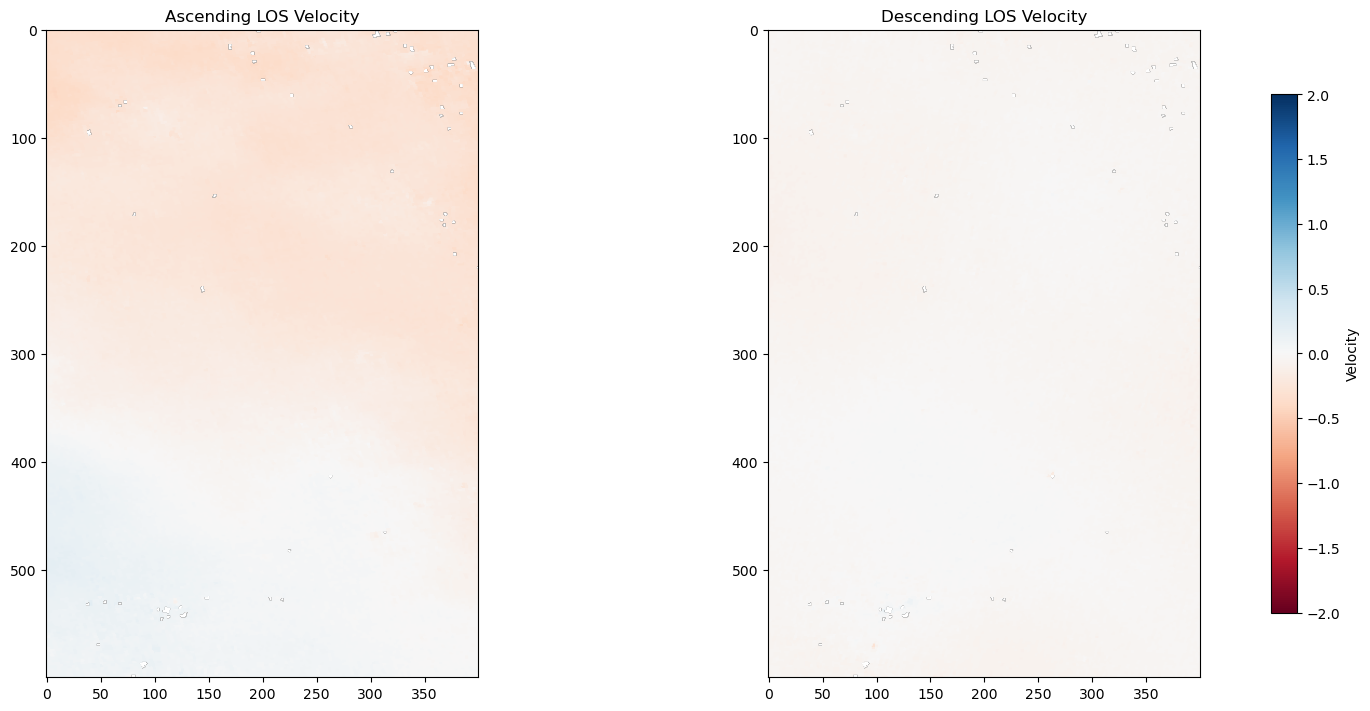

In [58]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    constrained_layout=True
)

im1 = axes[0].imshow(
    asc_vel,
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

axes[0].set_title("Ascending LOS Velocity")

im2 = axes[1].imshow(
    desc_vel,
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title("Descending LOS Velocity")

fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    shrink=0.8,
    label="Velocity"
)

plt.show()

Plot difference of LOS velocities

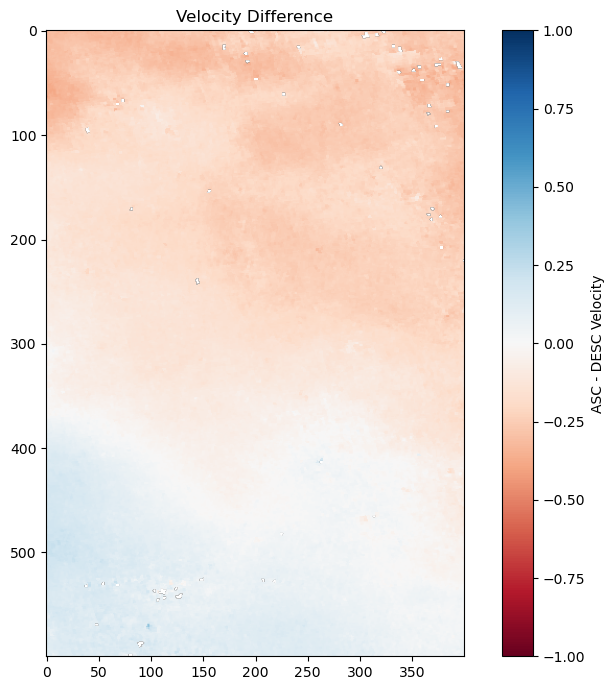

In [69]:
difference = asc_vel - desc_vel

plt.figure(figsize=(8, 7))

plt.imshow(
    difference,
    cmap="RdBu",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="ASC - DESC Velocity")

plt.title("Velocity Difference")

plt.tight_layout()
plt.show()

Statistics 

In [59]:
asc_stats = compute_statistics(asc_vel)
desc_stats = compute_statistics(desc_vel)

In [61]:
stats_df = pd.DataFrame({
    "Ascending": asc_stats,
    "Descending": desc_stats
})
stats_df.round(3)

,Ascending,Descending
count,239442.000,239442.000
min,-0.424,-0.289
max,0.206,0.154
mean,-0.137,-0.036
std,0.141,0.022
p01,-0.363,-0.083
p05,-0.320,-0.071
p50,-0.178,-0.036
p95,0.099,0.003
p99,0.146,0.012


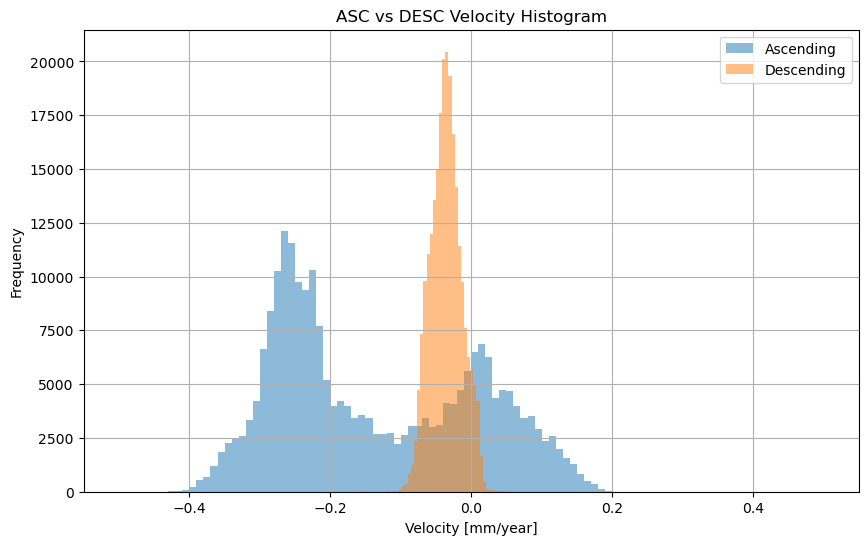

In [64]:
plt.figure(figsize=(10, 6))

# remove NaNs
asc_valid = asc_vel[np.isfinite(asc_vel)]
desc_valid = desc_vel[np.isfinite(desc_vel)]

# ascending histogram
plt.hist(
    asc_valid.flatten(),
    bins=100,
    alpha=0.5,
    label="Ascending",
    range=(-0.5,0.5)
)

# descending histogram
plt.hist(
    desc_valid.flatten(),
    bins=100,
    alpha=0.5,
    label="Descending",
)

plt.title("ASC vs DESC Velocity Histogram")

plt.xlabel("Velocity [mm/year]")
plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

# 5. Temporal Coherence Inspection

In [65]:
ASC_COH = ASC_GEO / "geo_temporalCoherence_commonMask.h5"
DESC_COH = DESC_GEO / "geo_temporalCoherence_commonMask.h5"

_, asc_coh = read_first_dataset(ASC_COH)
_, desc_coh = read_first_dataset(DESC_COH)

Plots

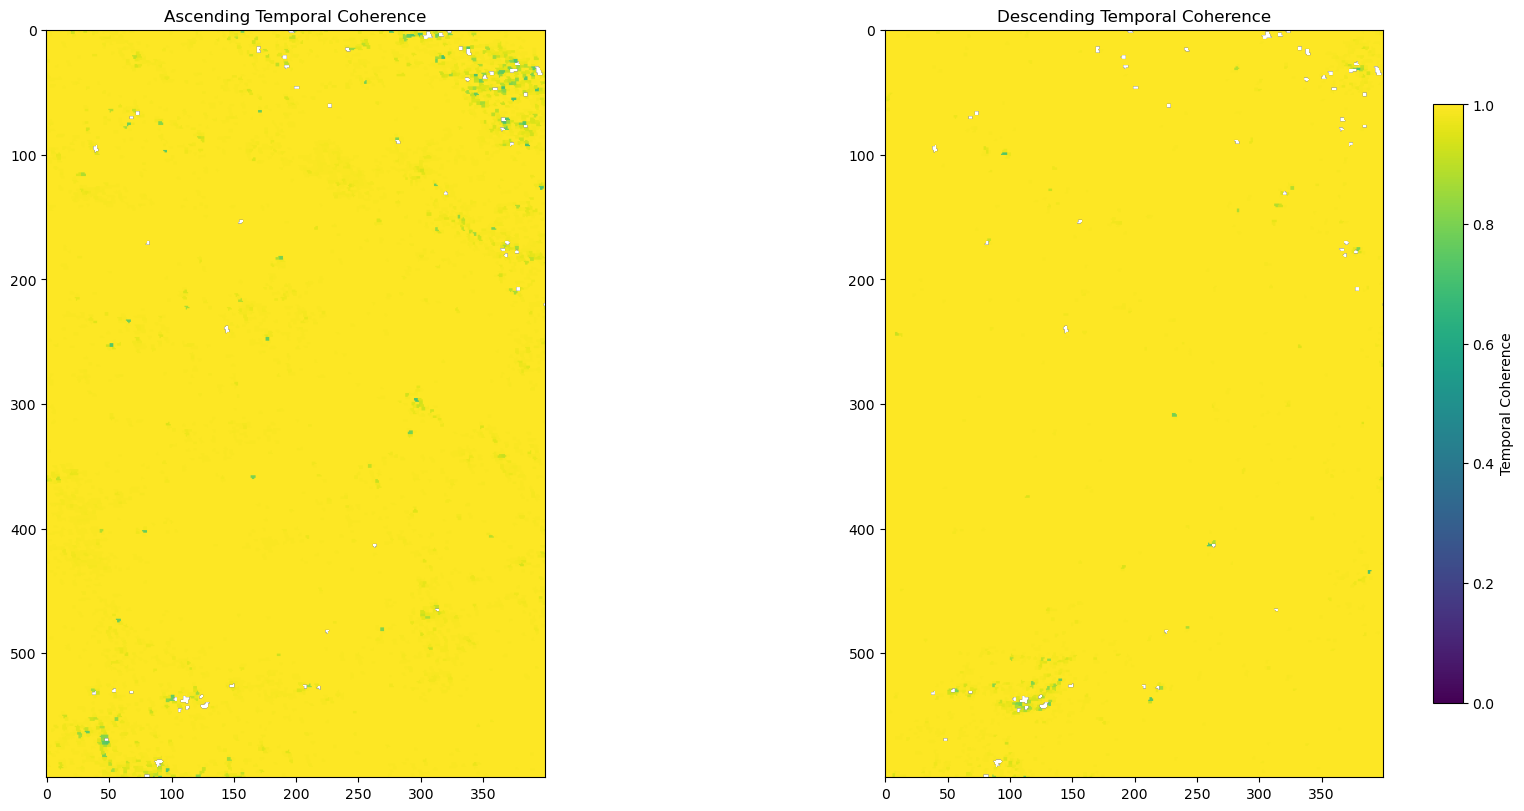

In [66]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    constrained_layout=True
)

# ---------------------------------------------------------
# ascending coherence
# ---------------------------------------------------------

im1 = axes[0].imshow(
    asc_coh,
    cmap="viridis",
    vmin=0,
    vmax=1
)

axes[0].set_title("Ascending Temporal Coherence")

# ---------------------------------------------------------
# descending coherence
# ---------------------------------------------------------

im2 = axes[1].imshow(
    desc_coh,
    cmap="viridis",
    vmin=0,
    vmax=1
)

axes[1].set_title("Descending Temporal Coherence")

# ---------------------------------------------------------
# shared colorbar
# ---------------------------------------------------------

cbar = fig.colorbar(
    im2,
    ax=axes,
    location="right",
    shrink=0.8,
    pad=0.03
)

cbar.set_label("Temporal Coherence")

plt.show()

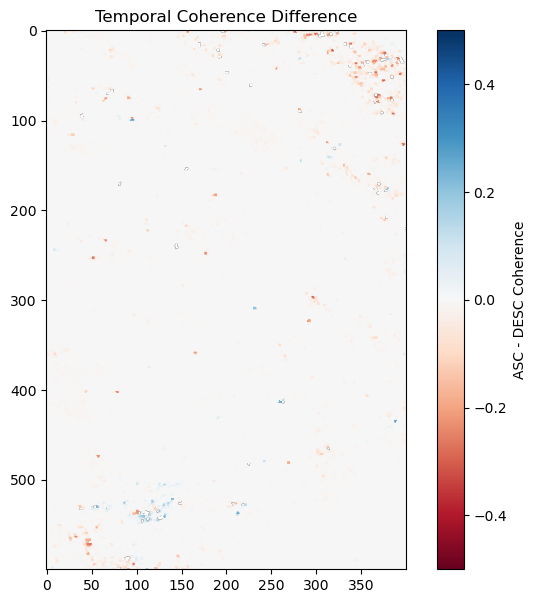

In [67]:
coh_diff = asc_coh - desc_coh

plt.figure(figsize=(8, 7))

plt.imshow(
    coh_diff,
    cmap="RdBu",
    vmin=-0.5,
    vmax=0.5
)

plt.colorbar(label="ASC - DESC Coherence")

plt.title("Temporal Coherence Difference")

plt.show()

Statistics

In [70]:
asc_coh_stats = compute_statistics(asc_coh)
desc_coh_stats = compute_statistics(desc_coh)

In [71]:
stats_df = pd.DataFrame({
    "Ascending": asc_coh_stats,
    "Descending": desc_coh_stats
})
stats_df.round(3)

,Ascending,Descending
count,239442.000,239442.000
min,0.708,0.717
max,1.000,1.000
mean,0.997,0.999
std,0.014,0.007
p01,0.950,0.989
p05,0.990,0.997
p50,0.999,1.000
p95,1.000,1.000
p99,1.000,1.000


# 6. Inspect Decomposition Outputs

## Vertical and east west velocity

In [72]:
VERTICAL = DECOMP_DIR / "vertical_velocity.h5"
EW = DECOMP_DIR / "eastwest_velocity.h5"

inspect_h5(VERTICAL)
inspect_h5(EW)


=== /home/lukasscharf/projects/ADUCAT/data/Mintpy_output/decomposition/vertical_velocity.h5 ===

Datasets:
  - velocity: (600, 400)

Attributes:
  ALOOKS: 2
  ANTENNA_SIDE: -1
  AZIMUTH_PIXEL_SIZE: 31.207048795077053
  BANDS: 2
  CENTER_INCIDENCE_ANGLE: 33.767067
  CENTER_LINE_UTC: 60185.0
  DATA_TYPE: float32
  DATE12: 20200604_20200628
  EARTH_RADIUS: 6371122.401798133
  END_DATE: 20200628
  FILE_LENGTH: 2092
  FILE_PATH: /data/Mintpy_output/stack_Ascending_73_20200604_20200628_c2_z2_r6_f0.5_mintpy/geo_standardized/geo_velocity_commonMask_ref.h5
  FILE_TYPE: velocity
  HEADING: -14.65023663425548
  HEIGHT: 702345.2046613393
  INTERLEAVE: BIL
  LAT_REF1: 47.8664671403763
  LAT_REF2: 48.025808478219176
  LAT_REF3: 48.379318655043456
  LAT_REF4: 48.53986177574492
  LENGTH: 600
  LON_REF1: 15.37213868638015
  LON_REF2: 16.627786332403147
  LON_REF3: 15.213430881256741
  LON_REF4: 16.488410458948383
  NCORRLOOKS: 7.1801243046996515
  NO_DATA_VALUE: none
  OG_FILE_PATH: /workspace/data/st

In [73]:
_, vertical = read_first_dataset(VERTICAL)

_, ew = read_first_dataset(EW)

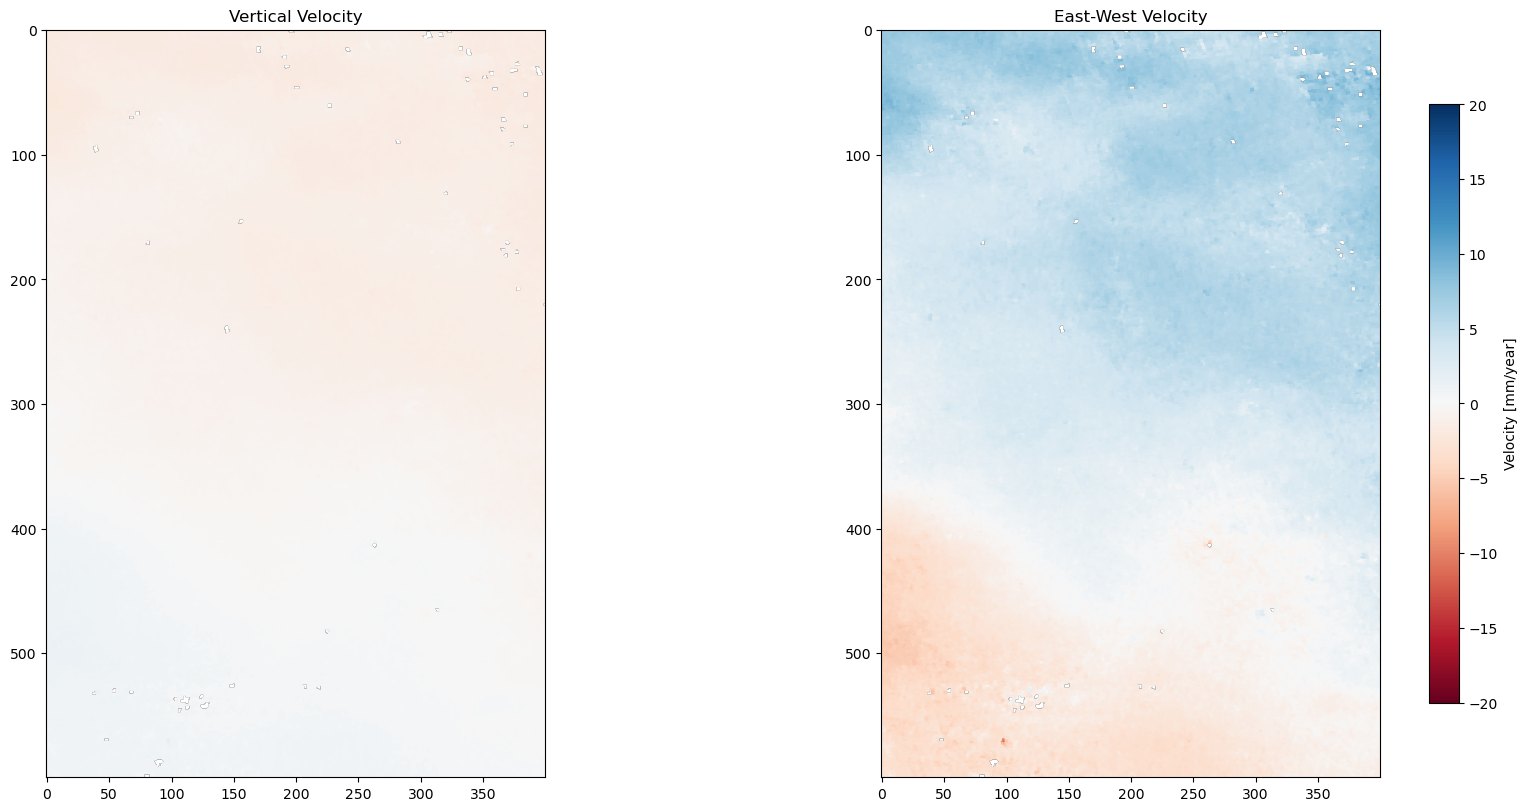

In [74]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    constrained_layout=True
)

# ---------------------------------------------------------
# vertical deformation
# ---------------------------------------------------------

im1 = axes[0].imshow(
    vertical,
    cmap="RdBu",
    vmin=-20,
    vmax=20
)

axes[0].set_title("Vertical Velocity")

# ---------------------------------------------------------
# east-west deformation
# ---------------------------------------------------------

im2 = axes[1].imshow(
    ew,
    cmap="RdBu",
    vmin=-20,
    vmax=20
)

axes[1].set_title("East-West Velocity")

# ---------------------------------------------------------
# shared colorbar
# ---------------------------------------------------------

cbar = fig.colorbar(
    im2,
    ax=axes,
    location="right",
    shrink=0.8,
    pad=0.03
)

cbar.set_label("Velocity [mm/year]")

plt.show()

In [75]:
vertical_stats = compute_statistics(vertical)
ew_stats = compute_statistics(ew)

In [77]:
decomp_stats = pd.DataFrame({
    "Vertical": vertical_stats,
    "East-West": ew_stats
})
decomp_stats.round(3)

,Vertical,East-West
count,239442.000,239442.000
min,-2.345,-11.130
max,2.187,10.142
mean,-0.612,2.432
std,0.771,3.290
p01,-1.870,-4.319
p05,-1.643,-3.321
p50,-0.776,3.044
p95,0.713,6.866
p99,0.957,7.823


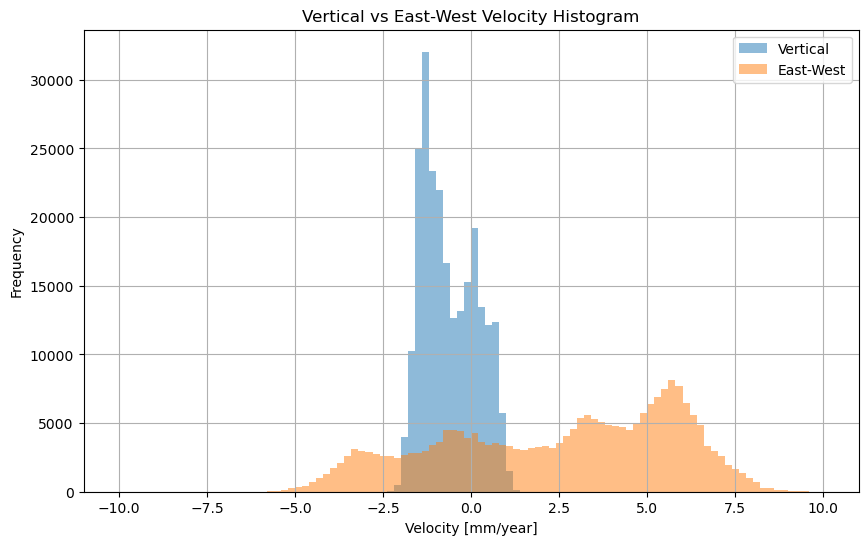

In [80]:
plt.figure(figsize=(10, 6))

# remove NaNs
vertical_valid = vertical[np.isfinite(vertical)]
ew_valid = ew[np.isfinite(ew)]

# vertical histogram
plt.hist(
    vertical_valid.flatten(),
    bins=100,
    alpha=0.5,
    label="Vertical",
    range=(-10, 10)
)

# east-west histogram
plt.hist(
    ew_valid.flatten(),
    bins=100,
    alpha=0.5,
    label="East-West",
    range=(-10, 10)
)

plt.title("Vertical vs East-West Velocity Histogram")

plt.xlabel("Velocity [mm/year]")
plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

# 8. Inspect Time Series

In [34]:
TIMESERIES = ASC_GEO / "geo_timeseries_commonMask.h5"

inspect_h5(TIMESERIES)


=== /home/lukasscharf/projects/ADUCAT/data/Mintpy_output/stack_Ascending_73_20200604_20200628_c2_z2_r6_f0.5_mintpy/geo_standardized/geo_timeseries_commonMask.h5 ===

Datasets:
  - bperp: (5,)
  - date: (5,)
  - timeseries: (5, 600, 400)

Attributes:
  ALOOKS: 2
  ANTENNA_SIDE: -1
  AZIMUTH_PIXEL_SIZE: 31.207048795077053
  BANDS: 2
  CENTER_INCIDENCE_ANGLE: 33.767067
  CENTER_LINE_UTC: 60185.0
  DATA_TYPE: float32
  DATE12: 200604-200610
  EARTH_RADIUS: 6371122.401798133
  END_DATE: 20200628
  FILE_LENGTH: 2092
  FILE_PATH: /data/Mintpy_output/stack_Ascending_73_20200604_20200628_c2_z2_r6_f0.5_mintpy/geo_standardized/geo_timeseries.h5
  FILE_TYPE: timeseries
  HEADING: -14.65023663425548
  HEIGHT: 702345.2046613393
  INTERLEAVE: BIL
  LAT_REF1: 47.8664671403763
  LAT_REF2: 48.025808478219176
  LAT_REF3: 48.379318655043456
  LAT_REF4: 48.53986177574492
  LENGTH: 600
  LON_REF1: 15.37213868638015
  LON_REF2: 16.627786332403147
  LON_REF3: 15.213430881256741
  LON_REF4: 16.488410458948383

In [35]:
with h5py.File(TIMESERIES, "r") as f:

    ts = f["timeseries"][:]

    dates = f["date"][:]

print(ts.shape)

(5, 600, 400)


## Example pixel

In [36]:
row = 250
col = 150

pixel_ts = ts[:, row, col]

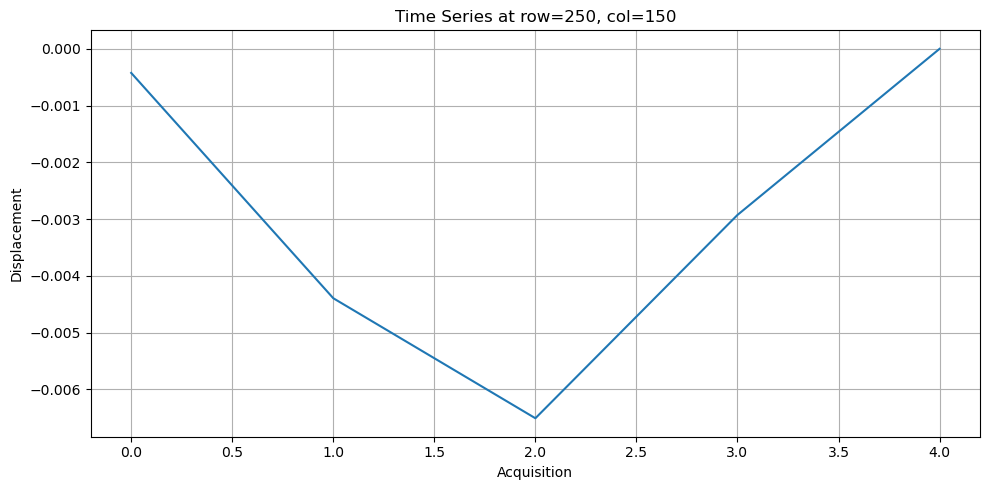

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(pixel_ts)

plt.title(f"Time Series at row={row}, col={col}")
plt.xlabel("Acquisition")
plt.ylabel("Displacement")

plt.grid(True)
plt.tight_layout()
plt.show()

# 9. Detect Strongest Subsidence Areas

In [38]:
valid = np.isfinite(vertical)

flat = vertical[valid]

threshold = np.percentile(flat, 1)

subsidence_mask = vertical <= threshold

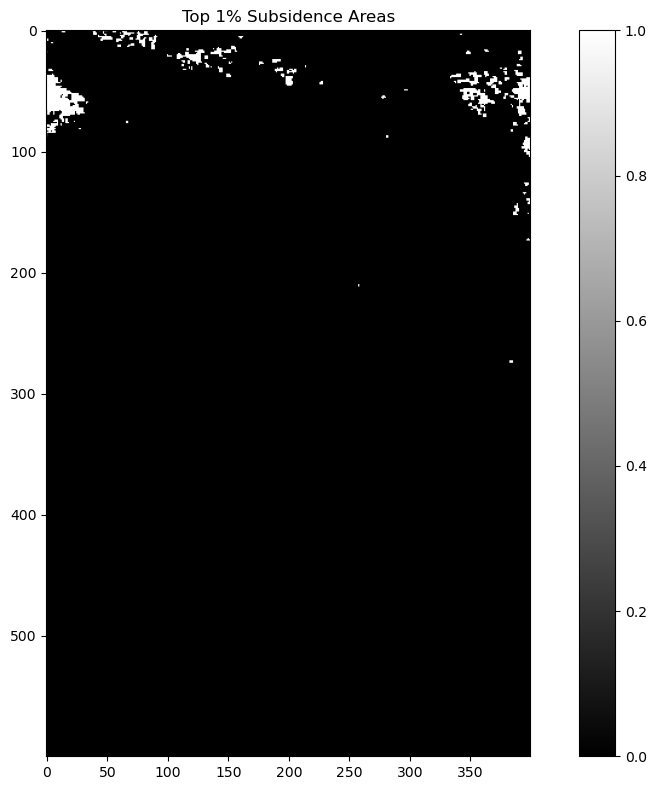

In [39]:
plot_raster(
    subsidence_mask,
    title="Top 1% Subsidence Areas",
    cmap="gray"
)

# 10. Export Points with Time Series

This is a first simple export format for frontend usage.

In [ ]:
with h5py.File(TIMESERIES, "r") as f:

    ts = f["timeseries"][:]

with h5py.File(ASC_GEO / "geo_geometryRadar.h5", "r") as f:

    lat = f["latitude"][:]
    lon = f["longitude"][:]

In [ ]:
mask = np.isfinite(vertical)

rows, cols = np.where(mask)

In [ ]:
records = []

for r, c in zip(rows[:5000], cols[:5000]):

    records.append({
        "lat": float(lat[r, c]),
        "lon": float(lon[r, c]),
        "vertical_velocity": float(vertical[r, c]),
        "eastwest_velocity": float(ew[r, c]),
        "timeseries": ts[:, r, c].tolist(),
    })

In [ ]:
points_df = pd.DataFrame(records)

points_df.head()

## Export to Parquet

In [ ]:
OUTFILE = BASE_DIR / "deformation_points.parquet"

points_df.to_parquet(OUTFILE)

print(OUTFILE)

## Export to GeoJSON

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

In [ ]:
geometry = [
    Point(xy)
    for xy in zip(points_df.lon, points_df.lat)
]

In [ ]:
gdf = gpd.GeoDataFrame(
    points_df,
    geometry=geometry,
    crs="EPSG:4326"
)

In [ ]:
geojson_out = BASE_DIR / "deformation_points.geojson"

## smaller sample for GeoJSON

In [ ]:
ngdf = gdf.iloc[:1000]

gdf.to_file(geojson_out, driver="GeoJSON")

print(geojson_out)

# 11. Next Ideas

Possible next extensions:

* interactive click-to-timeseries map
* cluster moving areas
* uncertainty analysis
* decomposition residuals
* export Cloud Optimized GeoTIFFs
* build deck.gl frontend
* PostGIS export
* STAC catalog generation
* PMTiles vector tiles
* displacement anomaly detection